# Phase 3 — LLM Medical Report Generation

This notebook demonstrates the LLM report generator. For each scan, we:
1. Predict the tumor class (Phase 1 model)
2. Generate a Grad-CAM heatmap (Phase 2)
3. Generate a structured preliminary report (Phase 3, via Groq)

Reports include Findings, Impression, Recommendation, and a mandatory Disclaimer.

In [1]:
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "app").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

from app.models.predictor import predict
from app.xai.gradcam import generate_heatmap
from app.llm.report_generator import generate_report

TEST_SAMPLES_DIR = project_root / "test_samples"
print("Ready. Test images:", len(list(TEST_SAMPLES_DIR.glob("*.jpg"))))

Ready. Test images: 12


Loading model from E:\Medical_AI_Platform\models\brain_tumor_densenet121.pth...
Model loaded and ready on cpu


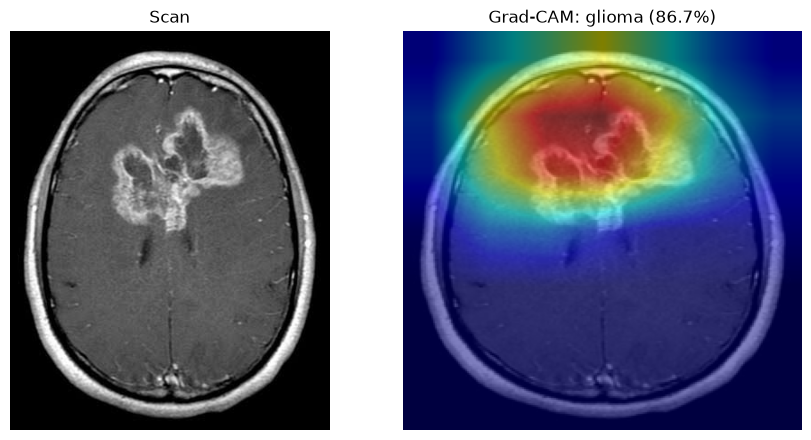

PREDICTION: glioma (86.8%)

FINDINGS:
The automated brain MRI classifier identified a glioma with a confidence of 86.8%. The Grad‑CAM heatmap indicates that the model focused on the image region most consistent with the glioma class. The full probability distribution across all classes is: glioma 86.8%, meningioma 11.4%, notumor 1.8%, pituitary 0.1%.

IMPRESSION:
The high confidence score suggests a strong likelihood of a glioma, but the presence of a non‑negligible probability for meningioma (11.4%) indicates that alternative diagnoses should still be considered. The Grad‑CAM localization supports the glioma hypothesis.

RECOMMENDATION:
A specialist neuroradiologist should review the findings. Consider additional imaging, such as contrast‑enhanced MRI sequences, and, if indicated, a biopsy for definitive diagnosis.

DISCLAIMER:
This report is an AI‑generated preliminary draft and does not constitute a medical diagnosis.



In [2]:
sample = TEST_SAMPLES_DIR / "glioma_1.jpg"

# 1. Predict
prediction = predict(sample)

# 2. Heatmap
heatmap, cls, conf = generate_heatmap(sample)

# 3. Report
report = generate_report(prediction)

# Show scan + heatmap
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(Image.open(sample).convert("RGB")); axes[0].set_title("Scan"); axes[0].axis("off")
axes[1].imshow(heatmap); axes[1].set_title(f"Grad-CAM: {cls} ({conf:.1%})"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# Show the structured report
print("PREDICTION:", prediction["predicted_class"], f'({prediction["confidence"]:.1%})\n')
for section, text in report["sections"].items():
    print(f"{section.upper()}:\n{text}\n")

One report per class

In [3]:
for cls in ["glioma", "meningioma", "notumor", "pituitary"]:
    sample = TEST_SAMPLES_DIR / f"{cls}_1.jpg"
    prediction = predict(sample)
    report = generate_report(prediction)
    print("=" * 70)
    print(f"TRUE CLASS: {cls}  |  PREDICTED: {prediction['predicted_class']} "
          f"({prediction['confidence']:.1%})")
    print("=" * 70)
    print(report["raw_report"])
    print()

TRUE CLASS: glioma  |  PREDICTED: glioma (86.8%)
FINDINGS: The automated classifier identified a glioma with a confidence of 86.8%. Grad‑CAM analysis indicates the model focused on the image region most consistent with a glioma. The probability distribution for other classes was: meningioma 11.4%, notumor 1.8%, pituitary 0.1%.

IMPRESSION: The model demonstrates high confidence in a glioma diagnosis. However, this is an automated assessment and should be interpreted in the context of clinical and radiographic evaluation.

RECOMMENDATION: A neuroradiology specialist should review the scan, and consider additional imaging or biopsy as appropriate for definitive diagnosis and management planning.

DISCLAIMER: This report is an AI-generated preliminary draft and does not constitute a medical diagnosis.

TRUE CLASS: meningioma  |  PREDICTED: meningioma (100.0%)
FINDINGS: The automated analysis of the brain MRI identified a lesion consistent with a meningioma. The model assigned a confidence

## Observations

*(After running, comment on:)*
- Do the reports honestly reflect confidence? (Check the low-confidence glioma cases especially.)
- Is the disclaimer always present?
- Are the four sections consistently structured?
- Does the report ever invent details not present in the input? (It should not.)